# IR Project 2026 — Demo & Evaluation

## 1. Project Overview

This notebook is a demonstration and evaluation walkthrough for the **IR Project 2026** information retrieval system, built on the `beir/webis-touche2020` argument retrieval dataset.

The system implements several retrieval and post-retrieval analysis services:

- **Preprocessing Service** — text normalization, tokenization, stopword removal, and lemmatization/stemming, shared by all retrieval models.
- **TF-IDF Search Service** — classic vector-space retrieval.
- **BM25 Search Service** — probabilistic ranking retrieval (the main production model).
- **Hybrid Serial / Hybrid Parallel Search Services** — combine BM25 with embedding-based semantic search.
- **Query Refinement Service** — conservative spelling correction and controlled synonym expansion.
- **Result Clustering Service** — groups retrieved results into topic-based clusters (post-retrieval analysis).
- **Topic Detection Service** — extracts the main topic terms from a query and its retrieved documents (post-retrieval analysis).

This notebook only **reads** existing artifacts (processed dataset, prebuilt indexes, evaluation outputs, charts) produced by the project's scripts. It does **not** modify any service or `app.py` code, and it does **not** run a full evaluation — it only demonstrates the already-built services on a few example queries.

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [13]:
import json

import pandas as pd
from IPython.display import Image, display

from config import (
    DATASET_INFO_PATH,
    EVALUATION_SUMMARY_PATH,
    PRECISION_CHART_PATH,
    RECALL_CHART_PATH,
    MAP_CHART_PATH,
    NDCG_CHART_PATH,
    TIME_CHART_PATH,
)
from services.preprocessing_service import preprocess_text
from services.bm25_search_service import BM25SearchService
from services.query_refinement_service import QueryRefinementService
from services.result_clustering_service import ResultClusteringService
from services.topic_detection_service import TopicDetectionService

## 2. Dataset Summary

Loaded from `data/processed/dataset_info.json`, the file produced by `scripts/prepare_dataset.py`.

In [14]:
with open(DATASET_INFO_PATH, "r", encoding="utf-8") as file:
    dataset_info = json.load(file)

documents_count = dataset_info.get("processed_docs_count")
queries_count = dataset_info.get("queries_count")
qrels_count = dataset_info.get("qrels_count")
unique_qrel_queries_count = dataset_info.get("unique_qrel_queries_count")

print(f"documents_count: {documents_count}")
print(f"queries_count: {queries_count}")
print(f"qrels_count: {qrels_count}")
print(f"unique_qrel_queries_count: {unique_qrel_queries_count}")

documents_count: 382545
queries_count: 49
qrels_count: 2962
unique_qrel_queries_count: 49


## 3. Preprocessing Demo

Running the shared `services.preprocessing_service.preprocess_text` pipeline (normalization → tokenization → stopword removal → lemmatization) on a sample query.

In [15]:
sample_query = "Should teachers get tenure?"

preprocessing_result = preprocess_text(sample_query)

print(f"original_text: {preprocessing_result['original_text']}")
print(f"cleaned_text: {preprocessing_result['cleaned_text']}")

original_text: Should teachers get tenure?
cleaned_text: teacher get tenure


## 4. BM25 Search Demo

Loading the prebuilt BM25 index (`data/indexes/bm25_*`) through `BM25SearchService` and searching for the same sample query.

In [16]:
bm25_service = BM25SearchService()

bm25_results = bm25_service.search(sample_query, top_k=20)

bm25_results_df = pd.DataFrame(
    [
        {
            "title": result["title"],
            "score": result["score"],
            "stance": result["stance"],
        }
        for result in bm25_results
    ]
)

bm25_results_df

,title,score,stance
0,Should Tenures Be Taken Away,26.272427,CON
1,There should not be a teacher tenure.,25.868284,PRO
2,There should not be a teacher tenure.,25.816835,PRO
3,Teacher Tenure,25.213478,CON
4,There should not be a teacher tenure.,25.104252,PRO
5,Colleges should abolish the ability for teache...,24.673250,CON
6,Should Tenures Be Taken Away,24.473537,CON
7,Should Tenures Be Taken Away,24.369394,PRO
8,Should Tenures Be Taken Away,23.869310,CON
9,The United States Federal Government ought to ...,23.772354,PRO


## 5. Query Refinement Demo

`QueryRefinementService` applies conservative spelling correction followed by controlled synonym expansion. Here we use a misspelled query to show the correction step.

In [17]:
query_refinement_service = QueryRefinementService()

misspelled_query = "Should techers get tenur?"

refinement_result = query_refinement_service.refine_query(misspelled_query)

print(f"original_query: {refinement_result['original_query']}")
print(f"corrected_query: {refinement_result['corrected_query']}")
print(f"expanded_query: {refinement_result['expanded_query']}")
print(f"corrections: {refinement_result['corrections']}")

original_query: Should techers get tenur?
corrected_query: should teachers get tenure
expanded_query: should teachers get tenure educator instructor job security protection
corrections: [{'original': 'techers', 'corrected': 'teachers'}, {'original': 'tenur', 'corrected': 'tenure'}]


## 6. Evaluation Summary

Loaded from `outputs/evaluation/evaluation_summary.json`, produced offline by `scripts/evaluate_models.py`. This notebook only reads the existing results — it does not re-run evaluation.

In [18]:
with open(EVALUATION_SUMMARY_PATH, "r", encoding="utf-8") as file:
    evaluation_summary = json.load(file)

evaluation_summary_df = pd.DataFrame(evaluation_summary)
evaluation_summary_df

,model,total_qrel_queries,loaded_processed_queries,evaluated_queries,missing_queries_count,failed_queries_count,missing_query_ids,failed_queries,top_k,precision_at_10,recall_at_100,map_at_100,ndcg_at_10,mean_time_seconds
0,tfidf,49,49,49,0,0,[],[],100,0.140816,0.180362,0.034858,0.053532,0.194546
1,bm25,49,49,49,0,0,[],[],100,0.630612,0.433301,0.243238,0.340807,0.032338
2,hybrid_serial,49,49,49,0,0,[],[],100,0.630612,0.433301,0.243849,0.341661,3.079143
3,hybrid_parallel,49,49,49,0,0,[],[],100,0.618367,0.433301,0.238735,0.329852,0.121703
4,bm25_refined_corrected,49,49,49,0,0,[],[],100,0.604082,0.414686,0.230683,0.325796,0.026840
5,bm25_refined_expanded,49,49,49,0,0,[],[],100,0.565306,0.401354,0.214547,0.314183,0.024701


In [19]:
bm25_summary = next(row for row in evaluation_summary if row["model"] == "bm25")

print(f"Number of evaluated queries: {bm25_summary['evaluated_queries']}")
print(f"Failed queries: {bm25_summary['failed_queries_count']}")

Number of evaluated queries: 49
Failed queries: 0


## 7. Charts

Pre-generated evaluation charts from `outputs/charts/`, produced by `scripts/generate_evaluation_charts.py`.

precision_at_10_comparison.png


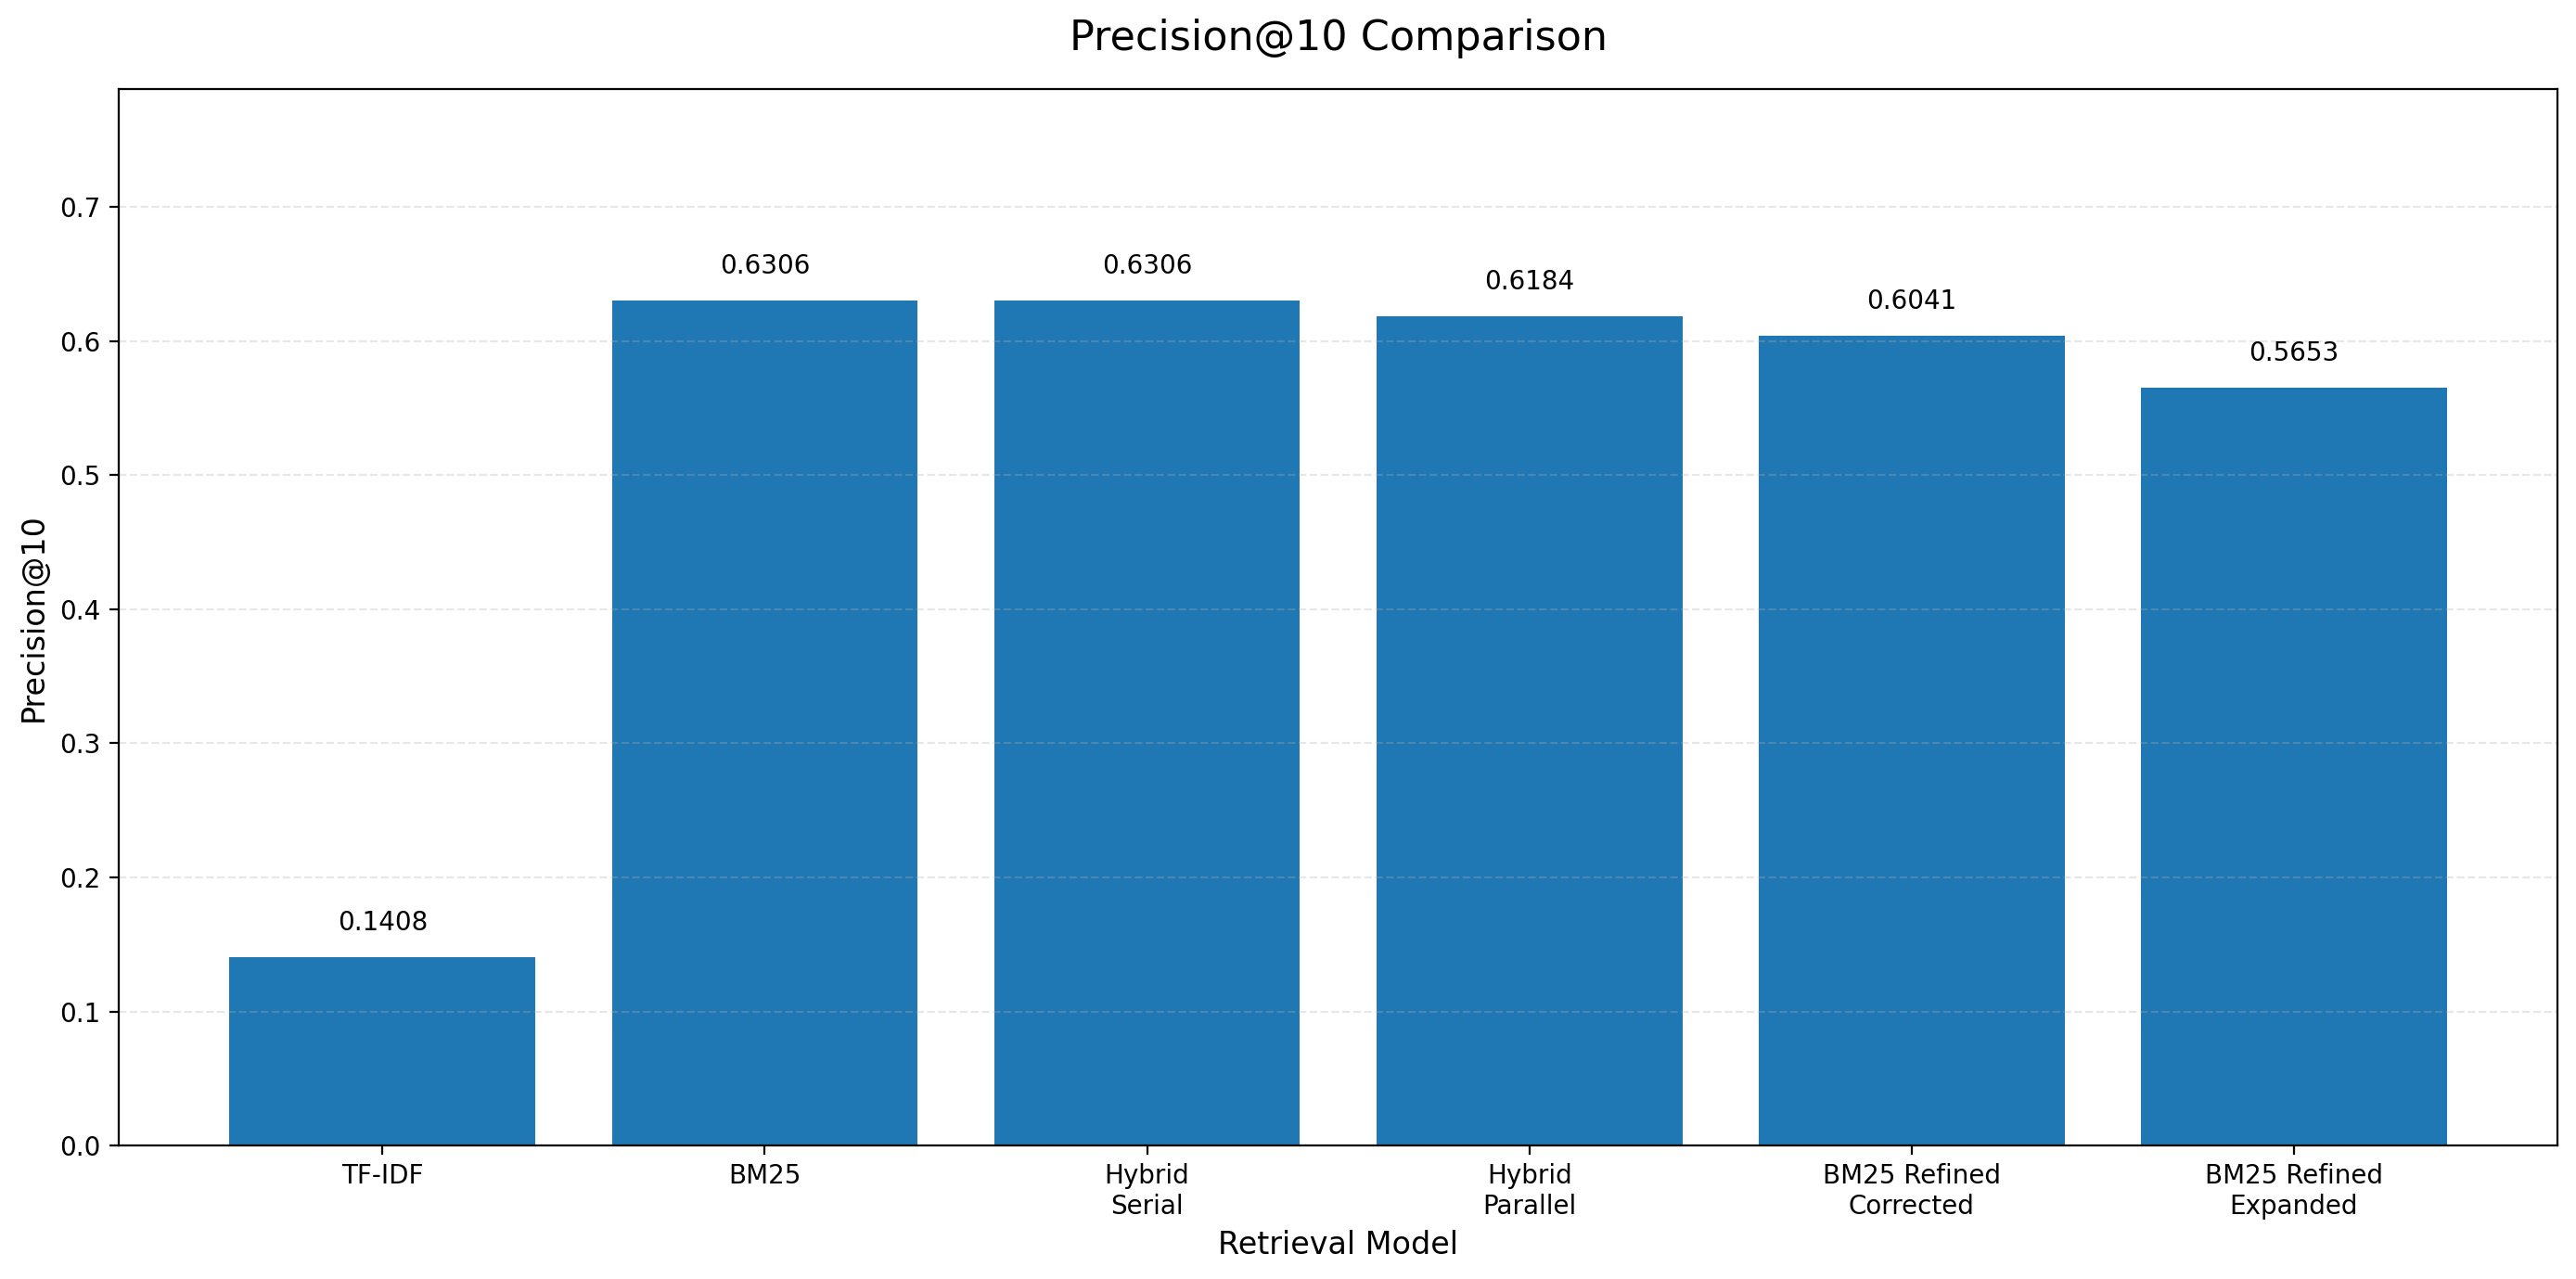

recall_at_100_comparison.png


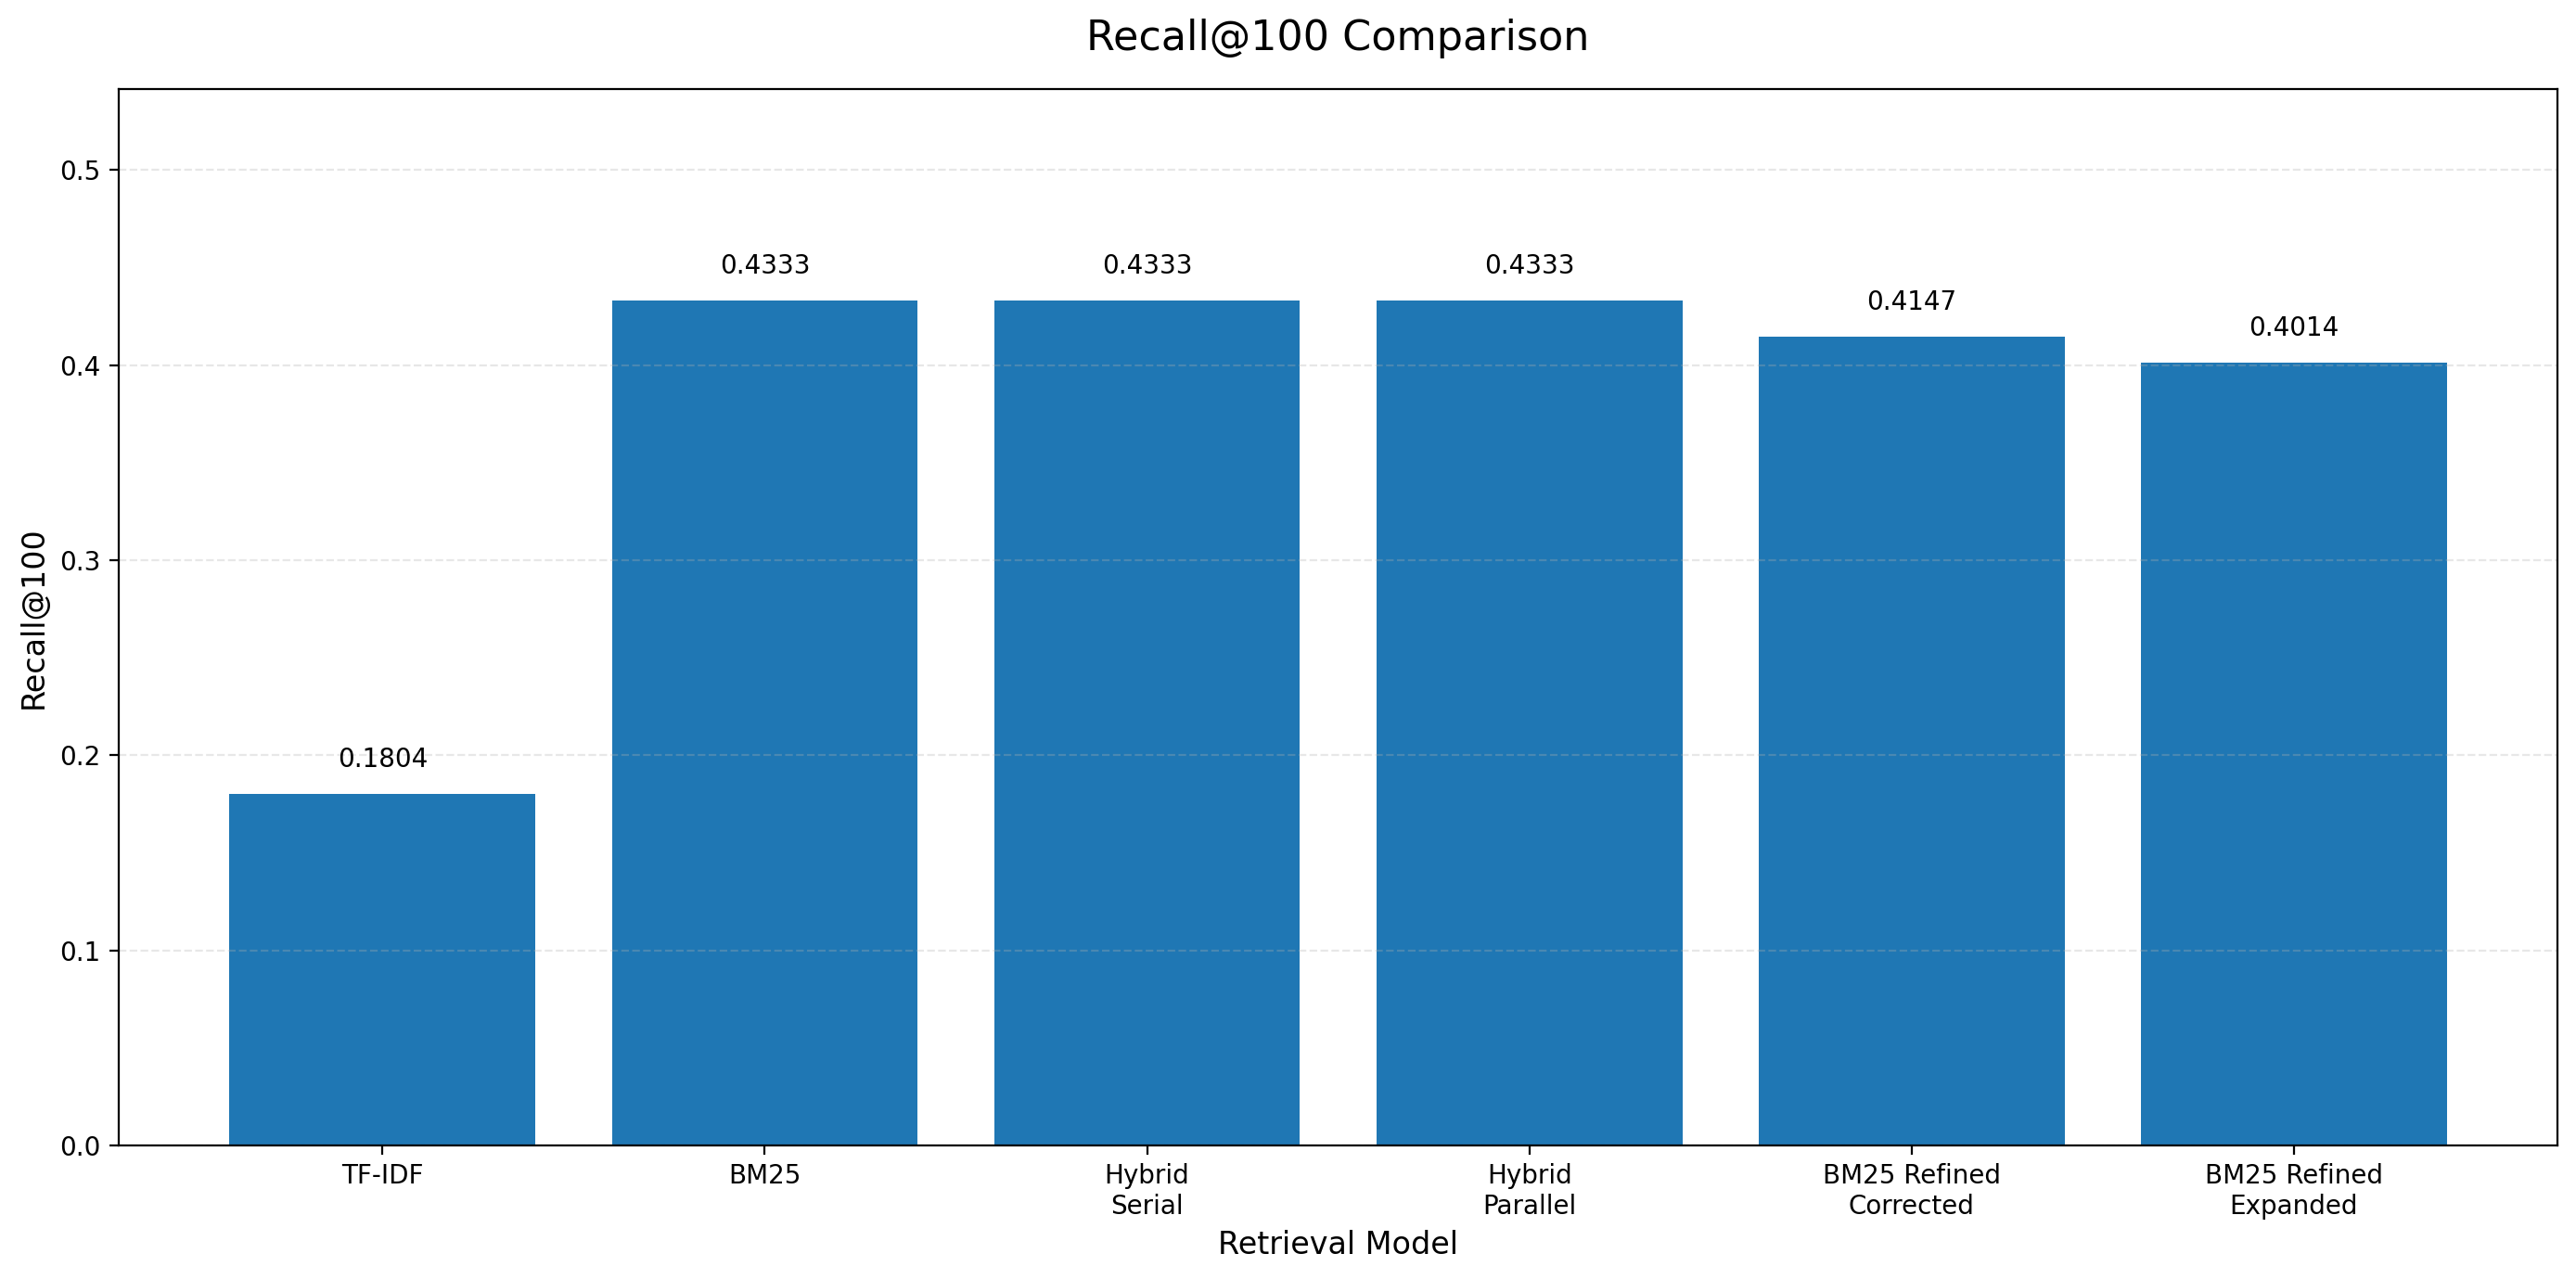

map_at_100_comparison.png


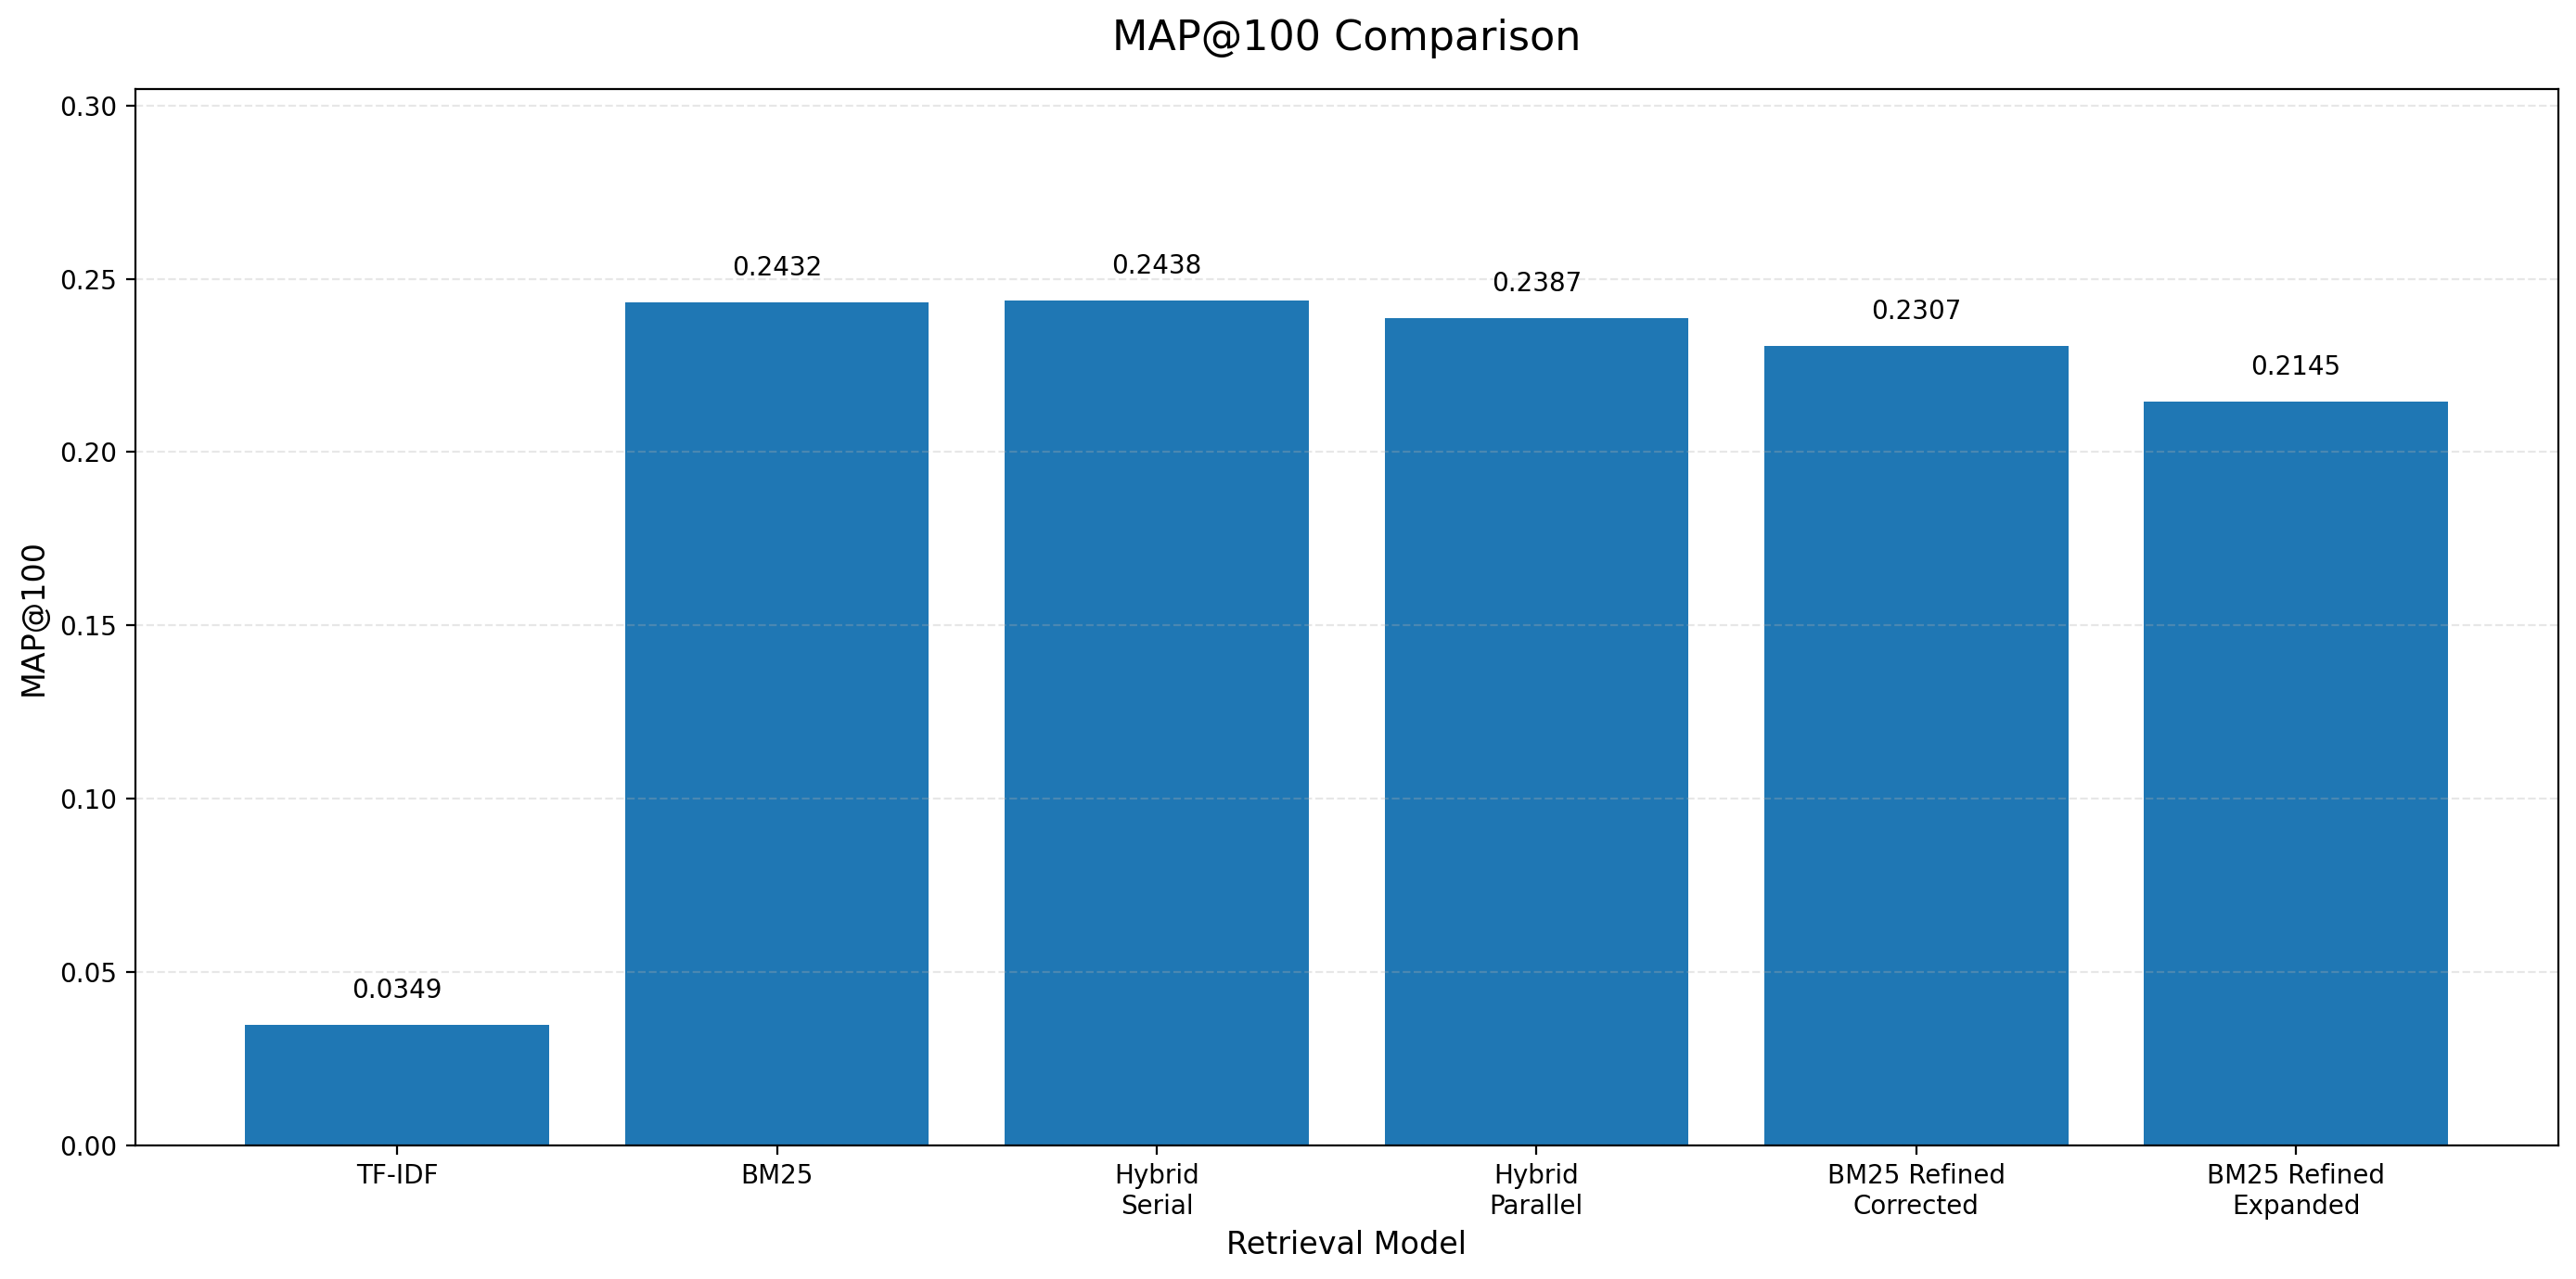

ndcg_at_10_comparison.png


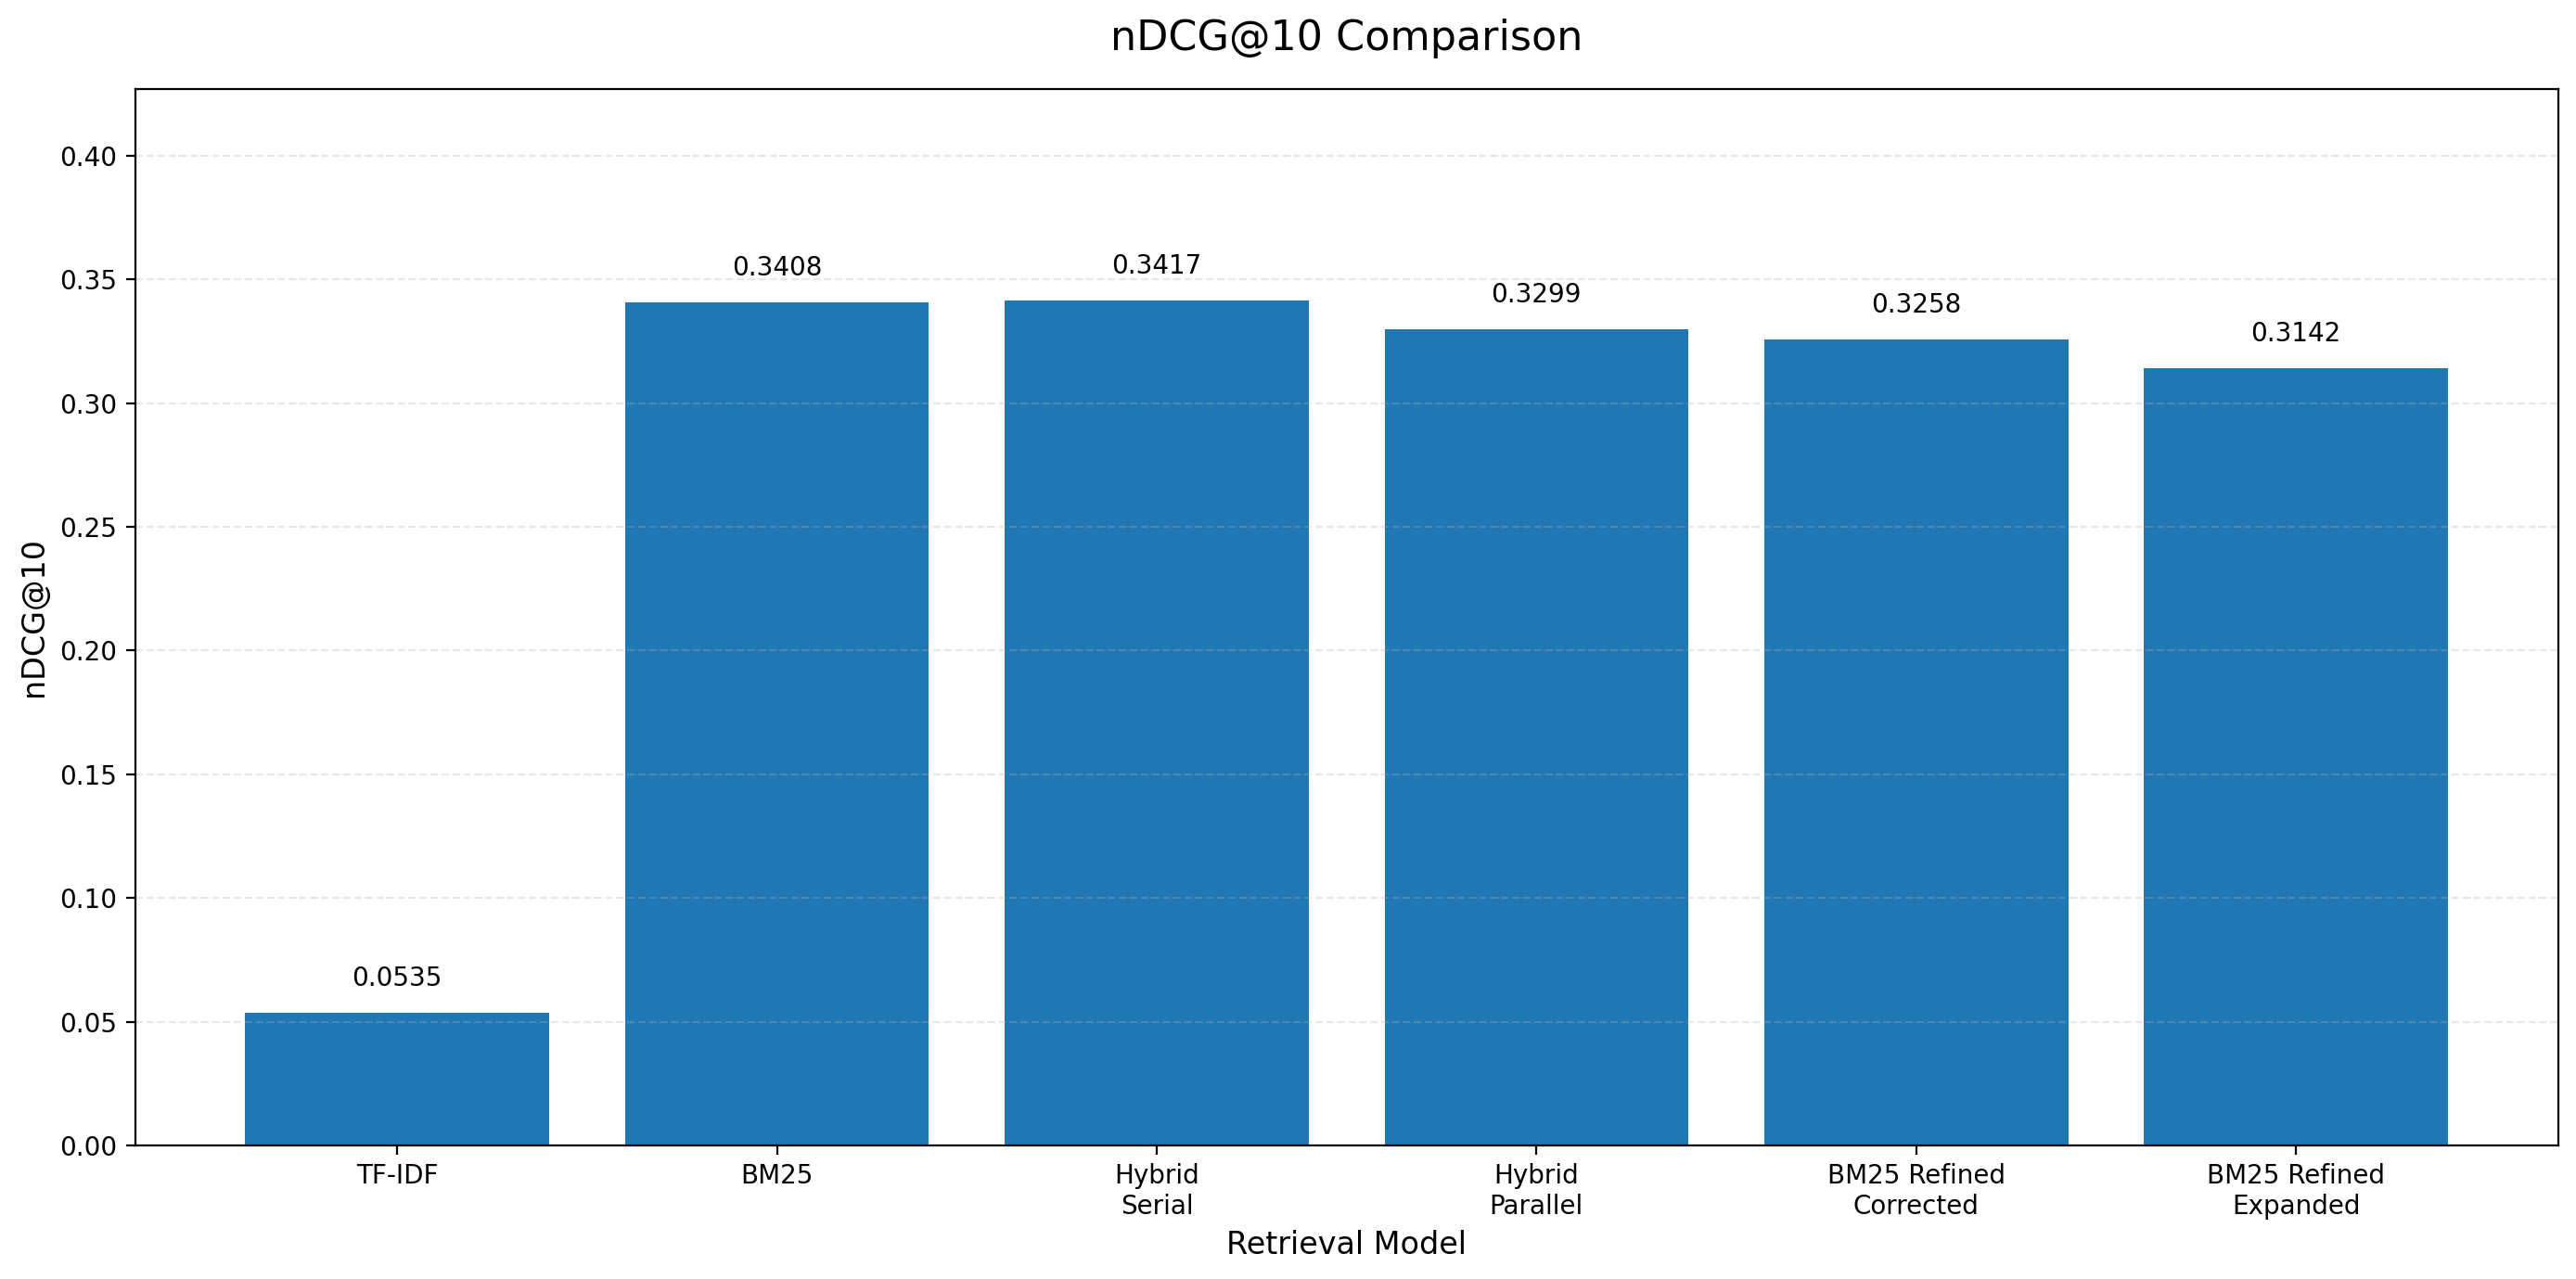

mean_query_time_comparison.png


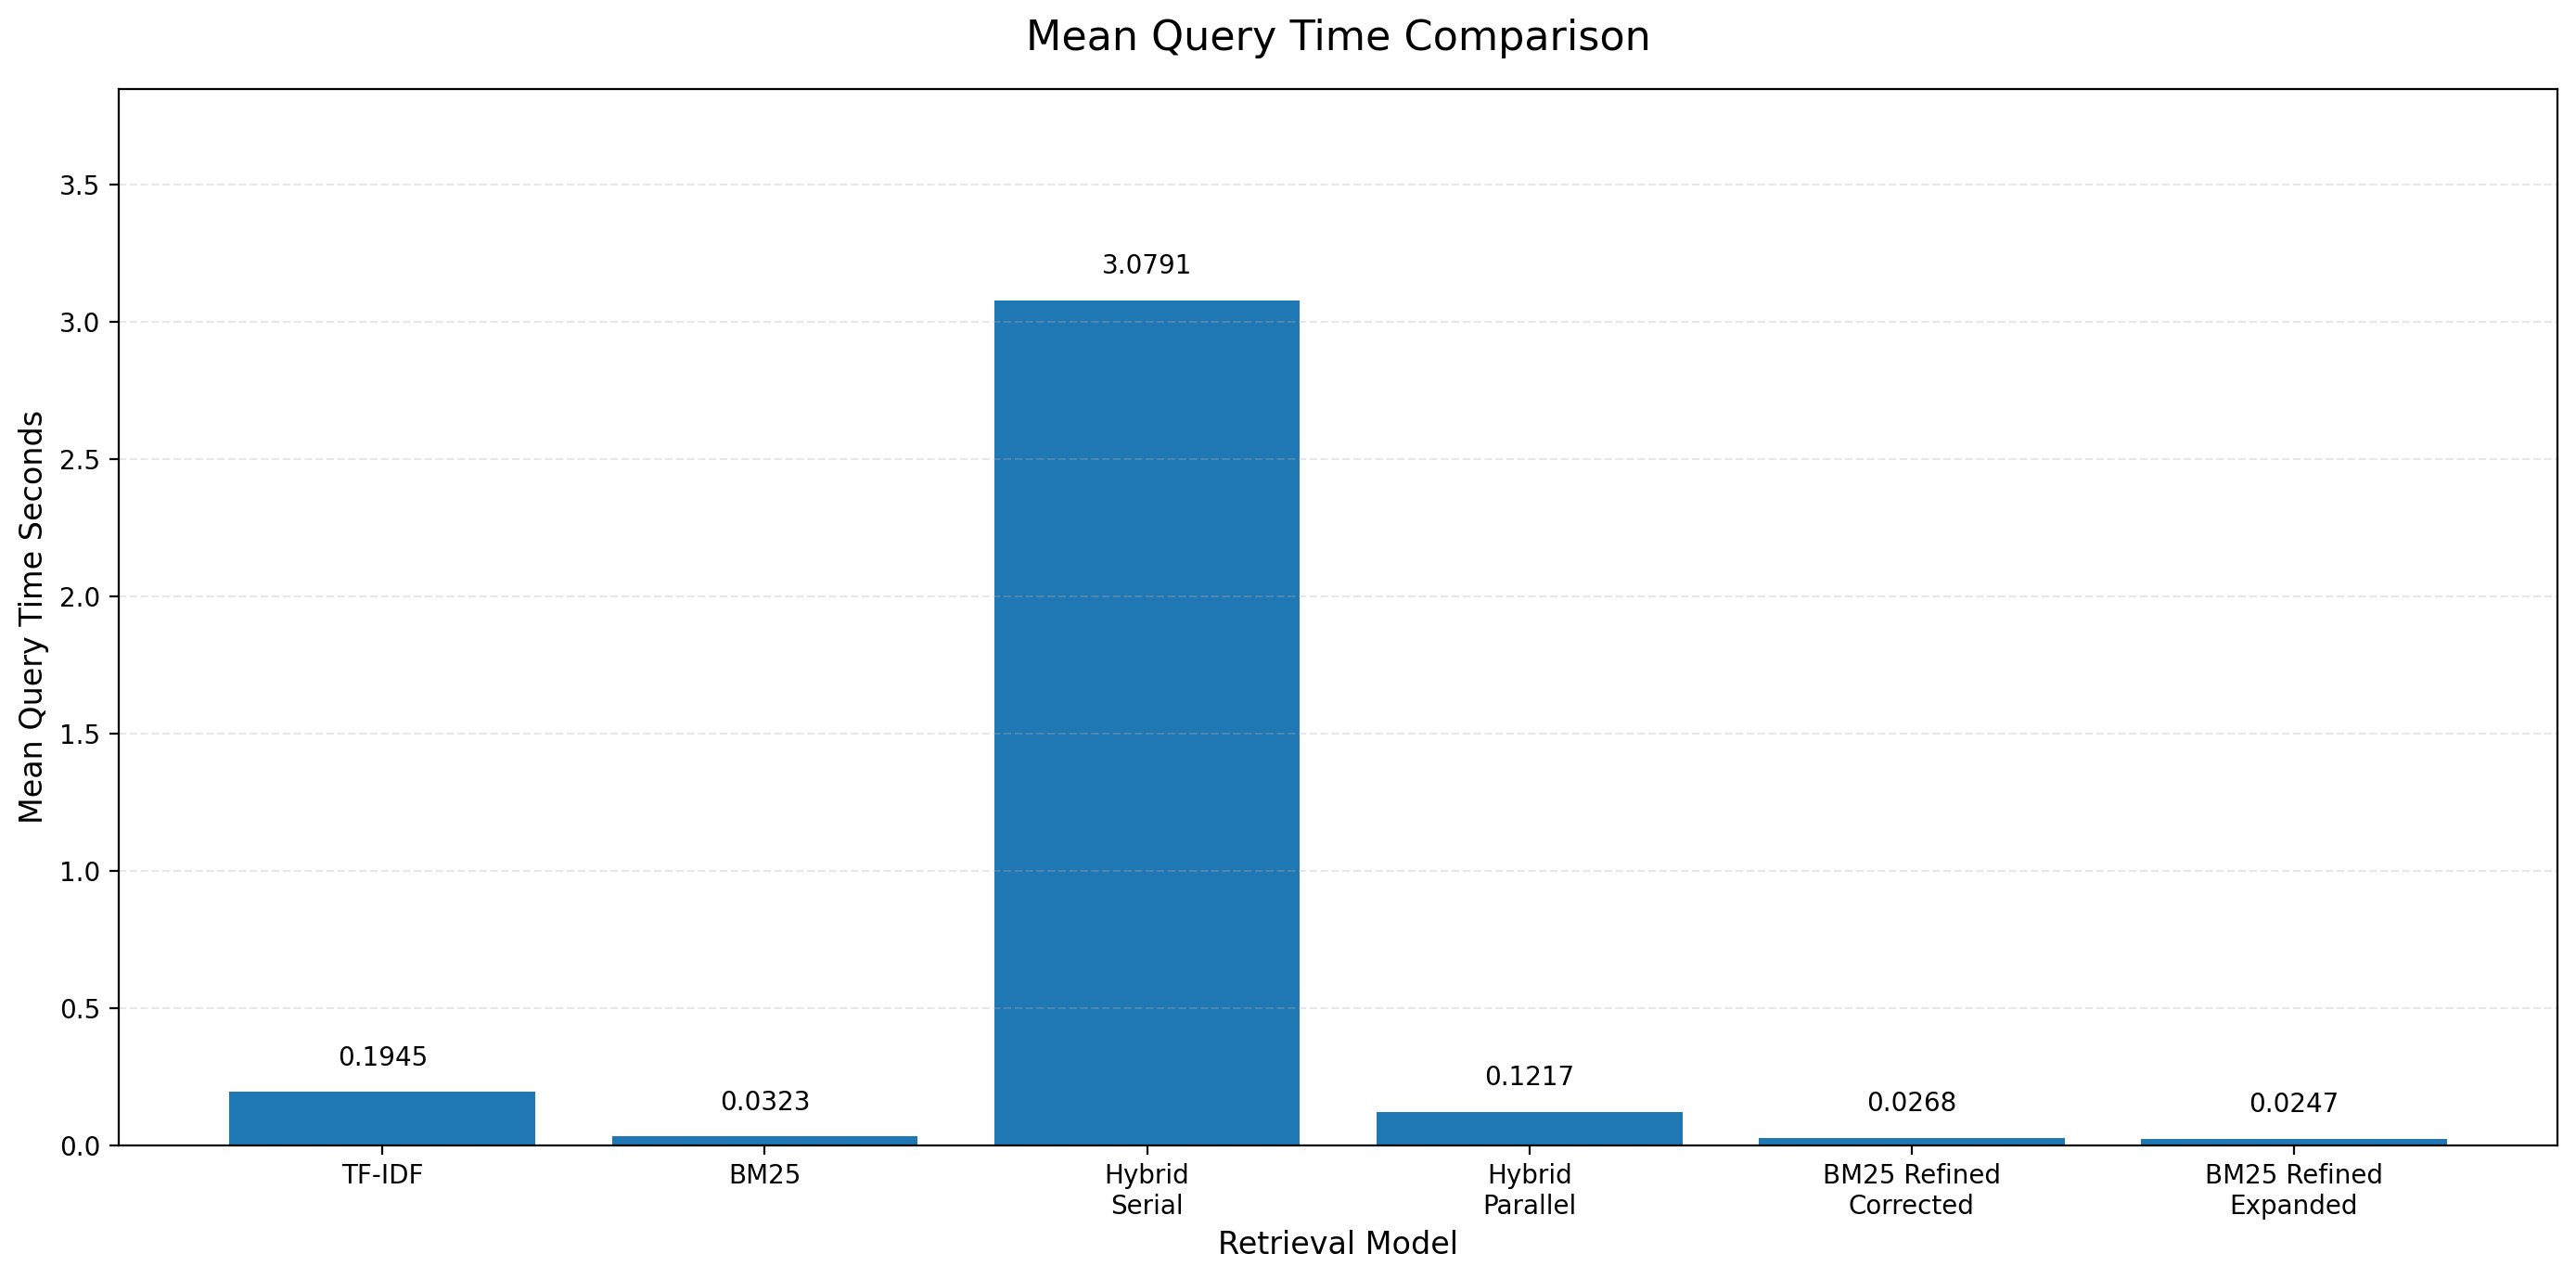

In [20]:
for chart_path in [
    PRECISION_CHART_PATH,
    RECALL_CHART_PATH,
    MAP_CHART_PATH,
    NDCG_CHART_PATH,
    TIME_CHART_PATH,
]:
    print(chart_path.name)
    display(Image(filename=str(chart_path)))

## 8. Extra Features: Result Clustering & Topic Detection

These are **post-retrieval analysis** services. They do not replace BM25/TF-IDF/Hybrid ranking — they run on top of the results that a retrieval model has already returned, to make the results easier to explore and understand.

- **`ResultClusteringService`** groups the retrieved documents into topic-based clusters using TF-IDF vectors over the result texts and KMeans clustering.
- **`TopicDetectionService`** extracts the dominant topic terms from the query plus the retrieved documents using TF-IDF term weighting.

Both are demonstrated below using the BM25 results obtained in Section 4.

In [21]:
result_clustering_service = ResultClusteringService()

clustering_result = result_clustering_service.cluster_results(bm25_results)

print(f"cluster_count: {clustering_result['cluster_count']}")

for cluster in clustering_result["clusters"]:
    print(f"- Cluster {cluster['cluster_id']} ({cluster['label']}): {cluster['size']} document(s)")

cluster_count: 3
- Cluster 1 (tenure / teachers / teacher): 10 document(s)
- Cluster 2 (tenures / teachers / fired): 7 document(s)
- Cluster 3 (teacher tenure / teacher / tenure): 3 document(s)


In [22]:
topic_detection_service = TopicDetectionService()

topic_result = topic_detection_service.detect_topic(sample_query, bm25_results)

print(f"topic_label: {topic_result['topic_label']}")
print(f"top_terms: {[term['term'] for term in topic_result['top_terms']]}")

topic_label: tenure / teachers / tenures / teacher
top_terms: ['tenure', 'teachers', 'tenures', 'teacher', 'teacher tenure', 'fired', 'school', 'teachers tenure', 'students', 'academic']


## 9. Conclusion

* **BM25** was the best practical retrieval model in this project because it achieved a strong balance between retrieval quality and query speed. It provided high Precision@10, MAP@100, and nDCG@10 while keeping the mean query time very low.

* **Hybrid Serial** achieved slightly better ranking quality on some metrics by combining BM25 with Sentence-BERT embedding-based reranking. However, it was noticeably slower because it performs an additional semantic reranking step after BM25 candidate retrieval.

* **Query Refinement** is useful when the user query contains spelling mistakes, such as `Should techers get tenur?`, because it can correct the query before sending it to BM25. However, on the official clean qrels queries, standard BM25 remained stronger.

* **Result Clustering** and **Topic Detection** are post-retrieval analysis features. They do not directly change ranking metrics such as Precision@10, Recall@100, MAP@100, or nDCG@10. Instead, they improve the explainability, organization, and usability of the retrieved results by helping users understand the main topics and subtopics inside the result set.

